# Project Title: Real-Time Face Segmentation for Movie Cast Identification

In [1]:
#Python Version
!python -V

Python 3.13.9


In [2]:
pip list

Package                   Version
------------------------- -----------
absl-py                   2.4.0
albucore                  0.0.24
albumentations            2.0.8
altair                    6.0.0
annotated-types           0.7.0
asttokens                 3.0.1
astunparse                1.6.3
attrs                     26.1.0
blinker                   1.9.0
cachetools                7.0.5
certifi                   2026.2.25
charset-normalizer        3.4.7
click                     8.3.2
colorama                  0.4.6
comm                      0.2.3
contourpy                 1.3.3
cycler                    0.12.1
debugpy                   1.8.20
decorator                 5.2.1
executing                 2.2.1
flatbuffers               25.12.19
fonttools                 4.62.1
gast                      0.7.0
gitdb                     4.0.12
GitPython                 3.1.46
google-pasta              0.2.0
grpcio                    1.80.0
h5py                      3.14.0
idna            

In [3]:
#Libraries used

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pprint
import albumentations as A

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, models

In [4]:
#Data Load

data = np.load("C:/Users/HP/Desktop/GUVI/Movie_Cast/Part 1- Train data - images.npy", allow_pickle=True)

c:\Users\HP\Desktop\GUVI\Movie_Cast\.venv\Lib\site-packages\numpy\lib\_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [5]:
# To see the dataset
print(type(data))
print(len(data))

print(type(data[0]))
print(np.shape(data[0]))

<class 'numpy.ndarray'>
409
<class 'numpy.ndarray'>
(2,)


In [6]:
img, mask = data[0]

print("Mask type:", type(mask))
print("Mask length:", len(mask))

print("Mask[0] type:", type(mask[0]))
print("Mask[1] type:", type(mask[1]))

Mask type: <class 'list'>
Mask length: 2
Mask[0] type: <class 'dict'>
Mask[1] type: <class 'dict'>


In [7]:
pprint.pprint(mask[0])

{'imageHeight': 333,
 'imageWidth': 650,
 'label': ['Face'],
 'notes': '',
 'points': [{'x': 0.08615384615384615, 'y': 0.3063063063063063},
            {'x': 0.1723076923076923, 'y': 0.45345345345345345}]}


It is not a list of numbers, Image is a list contains elements that are not consistent in shape or channels.I think that some of the images are still different internally.It is like mix of grayscale/RGB/alpha channel image.For this to find l, I need to run the following code

In [8]:
for i, img in enumerate(images):
    if img.shape != (256, 256, 3):
        print(i, img.shape)
        break

NameError: name 'images' is not defined

Some images are RGBA (4 Channels) and others are RGB (3 channels), RGBA is like Red, Green, Blue, Alpha (transparency) but the deep learning project is expecting RGB(Red, Green, Blue).So we must remove the alpha channel safely.

In [9]:
# To create the final mask from all annotations
import numpy as np
import cv2

def create_combined_mask(annotation_list, image_shape):
    h, w = image_shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)

    for ann in annotation_list:

        if 'points' in ann:
            pts = ann['points']

            # convert normalized → pixel coordinates
            pts = np.array([
                [int(p['x'] * w), int(p['y'] * h)]
                for p in pts
            ], dtype=np.int32)

            # IMPORTANT: check if only 2 points (bounding box case)
            if len(pts) == 2:
                x1, y1 = pts[0]
                x2, y2 = pts[1]
                cv2.rectangle(mask, (x1, y1), (x2, y2), 1, -1)

            else:
                cv2.fillPoly(mask, [pts], 1)

    return mask

In [10]:
# Building the datasets
import numpy as np
import cv2

images = []
masks = []

for item in data:
    img, annotations = item

    # --- FIX IMAGE CHANNELS ---
    if len(img.shape) == 2:  # grayscale
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    elif img.shape[2] == 4:  # RGBA → RGB (REMOVE ALPHA)
        img = cv2.cvtColor(img, cv2.COLOR_BGRA2RGB)

    else:  # already 3 channels
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # --- CREATE MASK ---
    mask = create_combined_mask(annotations, img.shape)

    # --- RESIZE ---
    img = cv2.resize(img, (256,256))
    mask = cv2.resize(mask, (256,256))

    images.append(img)
    masks.append(mask)

# --- FINAL CONVERSION ---
images = np.array(images, dtype=np.float32) / 255.0
masks = np.expand_dims(np.array(masks, dtype=np.float32), axis=-1)

In [11]:
# fixed
#Removal of alpha channel
#Convert Grayscale to RGB
#Standardized to (256, 256, 3)

print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


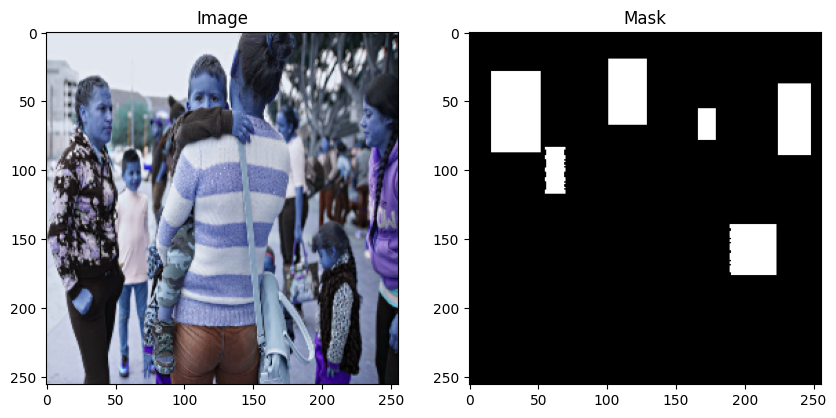

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(images[24])
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(masks[24].squeeze(), cmap='gray')
plt.title("Mask")

plt.show()

In [13]:
#In EDA part of this inputs(images), Nneed to ensure makes align with faces for the noise/errors detect early
print(images.shape)
print(masks.shape)

(409, 256, 256, 3)
(409, 256, 256, 1)


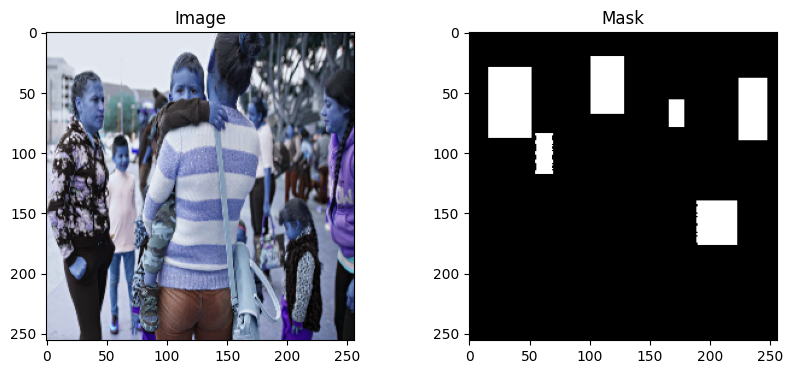

In [14]:
# Data Visualization
import matplotlib.pyplot as plt

def visualize_sample(i):
    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    plt.imshow(images[24])
    plt.title("Image")

    plt.subplot(1,2,2)
    plt.imshow(masks[24].squeeze(), cmap='gray')
    plt.title("Mask")

    plt.show()

visualize_sample(0)

In [15]:
#Data Augmentation
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.Rotate(limit=20, p=0.5),
    A.RandomBrightnessContrast(p=0.3)
])

In [16]:
#for the improvement of generalization to help achieve Dice > 0.92
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

In [17]:
# To achieve the custom metrics
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

def f1_score(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # threshold

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return 2 * (precision * recall) / (precision + recall + 1e-7)

In [18]:
# Building the Model
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    skips = [
        base.get_layer("block_1_expand_relu").output,   # 128x128
        base.get_layer("block_3_expand_relu").output,   # 64x64
        base.get_layer("block_6_expand_relu").output,   # 32x32
        base.get_layer("block_13_expand_relu").output   # 16x16
    ]

    x = base.output  # 8x8

    def up(x, skip):
        x = tf.keras.layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = tf.keras.layers.Concatenate()([x, skip])
        x = tf.keras.layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        return x

    # Decoder
    x = up(x, skips[3])  # 16x16
    x = up(x, skips[2])  # 32x32
    x = up(x, skips[1])  # 64x64
    x = up(x, skips[0])  # 128x128

    x = tf.keras.layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)  # → 256x256
    x = tf.keras.layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = tf.keras.layers.Conv2D(1, 1, activation='sigmoid')(x)

    return tf.keras.models.Model(base.input, outputs)

In [19]:
# To compile the model
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss,
    metrics=[dice_coefficient, iou, f1_score]
)

C:\Users\HP\AppData\Local\Temp\ipykernel_8956\4188440941.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


In [20]:
# Train-Test set splitting
X_train, X_val, y_train, y_val = train_test_split(
    images, masks, test_size=0.2, random_state=42
)

In [21]:
# Training with checkpoints
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=10,
    callbacks=callbacks
)

Epoch 1/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - dice_coefficient: 0.2260 - f1_score: 0.2265 - iou: 0.1282 - loss: 0.7740 

33/33 ━━━━━━━━━━━━━━━━━━━━ 922s 27s/step - dice_coefficient: 0.2563 - f1_score: 0.2595 - iou: 0.1485 - loss: 0.7450 - val_dice_coefficient: 0.4188 - val_f1_score: 0.3995 - val_iou: 0.2664 - val_loss: 0.5908
Epoch 2/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - dice_coefficient: 0.5556 - f1_score: 0.5642 - iou: 0.3911 - loss: 0.4444 

33/33 ━━━━━━━━━━━━━━━━━━━━ 870s 26s/step - dice_coefficient: 0.5984 - f1_score: 0.6028 - iou: 0.4326 - loss: 0.4005 - val_dice_coefficient: 0.6700 - val_f1_score: 0.6705 - val_iou: 0.5057 - val_loss: 0.3371
Epoch 3/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - dice_coefficient: 0.7110 - f1_score: 0.7114 - iou: 0.5540 - loss: 0.2890 

33/33 ━━━━━━━━━━━━━━━━━━━━ 904s 26s/step - dice_coefficient: 0.7248 - f1_score: 0.7252 - iou: 0.5704 - loss: 0.2754 - val_dice_coefficient: 0.6938 - val_f1_score: 0.6941 - val_iou: 0.5335 - val_loss: 0.3149
Epoch 4/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 863s 26s/step - dice_coefficient: 0.7679 - f1_score: 0.7682 - iou: 0.6258 - loss: 0.2325 - val_dice_coefficient: 0.6810 - val_f1_score: 0.6813 - val_iou: 0.5177 - val_loss: 0.3190
Epoch 5/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 858s 26s/step - dice_coefficient: 0.7893 - f1_score: 0.7896 - iou: 0.6539 - loss: 0.2104 - val_dice_coefficient: 0.6497 - val_f1_score: 0.6498 - val_iou: 0.4828 - val_loss: 0.3477
Epoch 6/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 850s 26s/step - dice_coefficient: 0.8023 - f1_score: 0.8025 - iou: 0.6724 - loss: 0.1974 - val_dice_coefficient: 0.6695 - val_f1_score: 0.6698 - val_iou: 0.5048 - val_loss: 0.3274
Epoch 7/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - dice_coefficient: 0.7914 - f1_score: 0.7916 - iou: 0.6577 - loss: 0.2086 

33/33 ━━━━━━━━━━━━━━━━━━━━ 851s 26s/step - dice_coefficient: 0.7989 - f1_score: 0.7990 - iou: 0.6682 - loss: 0.2017 - val_dice_coefficient: 0.6991 - val_f1_score: 0.6991 - val_iou: 0.5388 - val_loss: 0.3007
Epoch 8/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 25s/step - dice_coefficient: 0.8282 - f1_score: 0.8283 - iou: 0.7086 - loss: 0.1718 

33/33 ━━━━━━━━━━━━━━━━━━━━ 858s 26s/step - dice_coefficient: 0.8223 - f1_score: 0.8225 - iou: 0.7002 - loss: 0.1779 - val_dice_coefficient: 0.6938 - val_f1_score: 0.6939 - val_iou: 0.5326 - val_loss: 0.3003
Epoch 9/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 844s 26s/step - dice_coefficient: 0.8361 - f1_score: 0.8362 - iou: 0.7197 - loss: 0.1643 - val_dice_coefficient: 0.6873 - val_f1_score: 0.6873 - val_iou: 0.5254 - val_loss: 0.3045
Epoch 10/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 846s 26s/step - dice_coefficient: 0.8422 - f1_score: 0.8424 - iou: 0.7296 - loss: 0.1572 - val_dice_coefficient: 0.6860 - val_f1_score: 0.6861 - val_iou: 0.5242 - val_loss: 0.3095
Epoch 11/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 24s/step - dice_coefficient: 0.8581 - f1_score: 0.8583 - iou: 0.7526 - loss: 0.1419 

33/33 ━━━━━━━━━━━━━━━━━━━━ 817s 25s/step - dice_coefficient: 0.8578 - f1_score: 0.8580 - iou: 0.7522 - loss: 0.1421 - val_dice_coefficient: 0.6993 - val_f1_score: 0.6993 - val_iou: 0.5391 - val_loss: 0.2985
Epoch 12/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 807s 24s/step - dice_coefficient: 0.8522 - f1_score: 0.8524 - iou: 0.7446 - loss: 0.1481 - val_dice_coefficient: 0.6910 - val_f1_score: 0.6911 - val_iou: 0.5295 - val_loss: 0.3073
Epoch 13/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 792s 24s/step - dice_coefficient: 0.8450 - f1_score: 0.8450 - iou: 0.7345 - loss: 0.1552 - val_dice_coefficient: 0.6965 - val_f1_score: 0.6965 - val_iou: 0.5357 - val_loss: 0.3000
Epoch 14/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - dice_coefficient: 0.8627 - f1_score: 0.8628 - iou: 0.7614 - loss: 0.1373 

33/33 ━━━━━━━━━━━━━━━━━━━━ 793s 24s/step - dice_coefficient: 0.8679 - f1_score: 0.8680 - iou: 0.7690 - loss: 0.1318 - val_dice_coefficient: 0.6988 - val_f1_score: 0.6988 - val_iou: 0.5387 - val_loss: 0.2947
Epoch 15/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 789s 24s/step - dice_coefficient: 0.8830 - f1_score: 0.8831 - iou: 0.7918 - loss: 0.1172 - val_dice_coefficient: 0.6681 - val_f1_score: 0.6681 - val_iou: 0.5036 - val_loss: 0.3219
Epoch 16/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - dice_coefficient: 0.8817 - f1_score: 0.8818 - iou: 0.7892 - loss: 0.1183 

33/33 ━━━━━━━━━━━━━━━━━━━━ 803s 24s/step - dice_coefficient: 0.8808 - f1_score: 0.8809 - iou: 0.7886 - loss: 0.1181 - val_dice_coefficient: 0.6986 - val_f1_score: 0.6986 - val_iou: 0.5383 - val_loss: 0.2923
Epoch 17/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 23s/step - dice_coefficient: 0.8920 - f1_score: 0.8921 - iou: 0.8070 - loss: 0.1080 

33/33 ━━━━━━━━━━━━━━━━━━━━ 789s 24s/step - dice_coefficient: 0.8897 - f1_score: 0.8898 - iou: 0.8028 - loss: 0.1101 - val_dice_coefficient: 0.7011 - val_f1_score: 0.7012 - val_iou: 0.5414 - val_loss: 0.2899
Epoch 18/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 790s 24s/step - dice_coefficient: 0.9011 - f1_score: 0.9013 - iou: 0.8209 - loss: 0.0988 - val_dice_coefficient: 0.6815 - val_f1_score: 0.6815 - val_iou: 0.5191 - val_loss: 0.3066
Epoch 19/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 790s 24s/step - dice_coefficient: 0.9029 - f1_score: 0.9030 - iou: 0.8239 - loss: 0.0968 - val_dice_coefficient: 0.6915 - val_f1_score: 0.6915 - val_iou: 0.5302 - val_loss: 0.2985
Epoch 20/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 793s 24s/step - dice_coefficient: 0.9058 - f1_score: 0.9059 - iou: 0.8289 - loss: 0.0944 - val_dice_coefficient: 0.6849 - val_f1_score: 0.6849 - val_iou: 0.5221 - val_loss: 0.3070
Epoch 21/30
33/33 ━━━━━━━━━━━━━━━━━━━━ 818s 25s/step - dice_coefficient: 0.9156 - f1_score: 0.9157 - iou: 0.8451 - loss: 0.0840 - val_di

In [22]:
# To verify the model output
model = build_unet()
model.summary()

C:\Users\HP\AppData\Local\Temp\ipykernel_8956\4188440941.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 128, 128,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 128, 128,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 128, 128,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 128, 128,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 128, 128,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 128, 128,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 128, 128,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 128, 128,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 129, 129,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 64, 64,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 64, 64,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 64, 64,    │      2,304 │ block_1_depthwis

 Total params: 9,243,969 (35.26 MB)

 Trainable params: 9,209,857 (35.13 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [23]:
print(model.output_shape)

(None, 256, 256, 1)


In [24]:
# Compile the Model (Fixes the ValueError)
# Since your mask is Black & White, we use Binary 

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.MeanIoU(num_classes=2)]
)

In [25]:
# To save the model
model.save("first_version_model.keras")

In [26]:
# To evaluate the model
model.evaluate(X_val, y_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 9s/step - accuracy: 0.3348 - loss: 0.7799 - mean_io_u: 0.4353


[0.7799118161201477, 0.3348252773284912, 0.4352979063987732]

In [27]:
# To see the predictions

def predict_and_overlay(model, image, threshold=0.5):
    # 1. Prepare image for prediction (Add batch dimension)
    img_input = np.expand_dims(image, axis=0)
    
    # 2. Get prediction from model
    prediction = model.predict(img_input)[0]
    
    # 3. Create a binary mask (pixels above 0.5 threshold)
    mask = (prediction > threshold).astype(np.uint8)
    
    # 4. Make sure mask is 2D (Squeeze out extra dimensions)
    # This fixes the IndexError!
    if len(mask.shape) == 3:
        mask = mask[:, :, 0] 
        
    # 5. Create the overlay
    overlay = image.copy()
    
    # Apply green color [0, 255, 0] where mask is 1
    # Since mask is now 2D, we just use mask == 1
    overlay[mask == 1] = [0, 255, 0] 
    
    # Blend for a "see-through" effect
    final_img = cv2.addWeighted(image, 0.7, overlay, 0.3, 0)
    
    return final_img

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


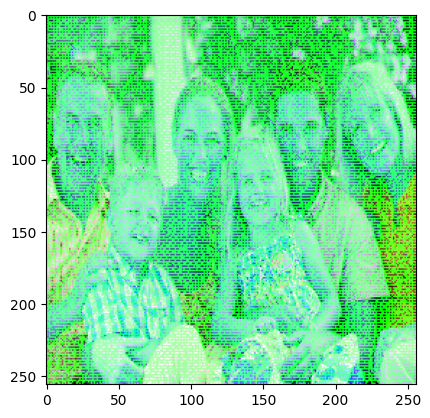

In [28]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

In [29]:
# results = model.evaluate(X_val, y_val)

print(f"Loss: {result[0]}")
print(f"Dice: {result[1]}")
print(f"IoU: {result[2]}")

Loss: [[4.11764719e-02 7.66015701e+01 1.37254909e-01]
 [5.49019612e-02 1.49019614e-01 1.96078435e-01]
 [1.01960786e-01 1.64705887e-01 2.31372550e-01]
 [2.23529413e-01 2.11764708e-01 3.88235301e-01]
 [1.97647065e-01 7.66647034e+01 3.26666653e-01]
 [2.50980407e-01 2.54901975e-01 4.58823532e-01]
 [1.80392161e-01 2.39215687e-01 3.60784322e-01]
 [1.13725491e-01 2.15686277e-01 2.86274523e-01]
 [1.05882354e-01 2.39215687e-01 2.70588249e-01]
 [1.05882354e-01 2.47058824e-01 2.78431386e-01]
 [1.33333340e-01 2.62745112e-01 3.13725501e-01]
 [1.80392161e-01 2.74509817e-01 3.56862754e-01]
 [2.15686277e-01 2.82352954e-01 4.15686280e-01]
 [2.31372550e-01 2.54901975e-01 4.39215690e-01]
 [2.54901975e-01 2.43137255e-01 4.86274511e-01]
 [2.98039228e-01 2.27450982e-01 5.52941203e-01]
 [2.00392172e-01 7.66399994e+01 3.76078457e-01]
 [3.01960796e-01 1.88235298e-01 5.60784340e-01]
 [3.17647070e-01 2.19607845e-01 5.80392182e-01]
 [3.25490206e-01 2.35294119e-01 5.96078455e-01]
 [2.22352952e-01 7.66564713e+01 4.

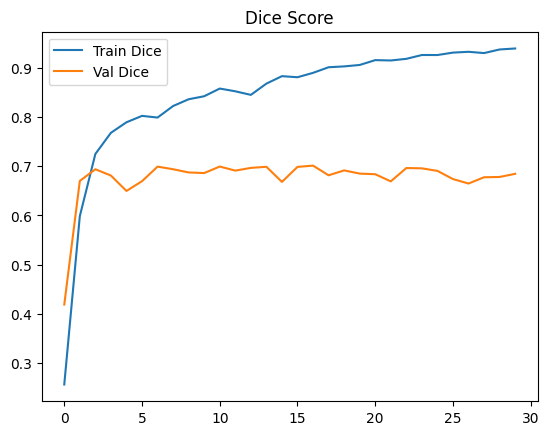

In [30]:
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

Validate the results and plan for the next level actions.

| Epoch | Train Dice | Val Dice |
| ----- | ---------- | -------- |
| 1     | 0.47       | 0.68     |
| 5     | 0.76       | 0.70     |
| 10    | 0.82       | 0.67     |
| 15    | 0.87       | 0.65     |

What I observed from this,

Training Dice is increasing at the same time validation dice is decreasing.I think that the model overfitting is happerning due to less data, so model is memorizing the train data nut not generalizing.I confirmed that,the pipeline is correct and model also learning properly.I need to improve it towards the meet requirements.

Root Causes

I could see some findings based on the results

1. Weak Masks - Here, I am using bounding boxes, not exact face for finding the faces.
2. Small Dataset - Deep learning needs more data
3. Not much strong Augmentaion

#### The steps to improve the performance
Loss → Augmentation → Model → Training → Post-processing

In [31]:
# Loss function using bce(pixel wise accuracy) + Dice(for overlapping)
def dice_coefficient(y_true, y_pred):
    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)
    intersection = tf.reduce_sum(y_true * y_pred)
    return (2 * intersection + 1) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + 1)

def combined_loss(y_true, y_pred):
    bce = tf.keras.losses.BinaryCrossentropy()(y_true, y_pred)
    dice = dice_coefficient(y_true, y_pred)
    return bce + (1 - dice)

def iou(y_true, y_pred):
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) - intersection
    return intersection / (union + 1e-7)

def f1_score(y_true, y_pred):
    y_pred = tf.cast(y_pred > 0.5, tf.float32)  # threshold

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + 1e-7)
    recall = tp / (tp + fn + 1e-7)

    return 2 * (precision * recall) / (precision + recall + 1e-7)

In [32]:
# Strong Augmentation augmentation parameters to situmulates real world scenes,So that I could prevent from the overfitting issues
augment_final = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=30, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.GaussianBlur(p=0.3),
    A.HueSaturationValue(p=0.3)
])

In [33]:
# Increasing the dataset, so that I can reducing the overfitting issue
def augment_data(images, masks):
    aug_images, aug_masks = [], []

    for img, mask in zip(images, masks):
        augmented = augment(image=img, mask=mask)
        aug_images.append(augmented['image'])
        aug_masks.append(augmented['mask'])

    return np.array(aug_images), np.array(aug_masks)

# Apply
X_train_aug, y_train_aug = augment_data(X_train, y_train)

# Combine original + augmented
X_train = np.concatenate([X_train, X_train_aug])
y_train = np.concatenate([y_train, y_train_aug])

In [34]:
# Re-building the model- Freeze the encoder for preventing the overfitting, Droppping out something for better generalization,Extra ensample for the fixing the shape mismatch
def build_unet(input_shape=(256,256,3)):
    base = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the encoder
    for layer in base.layers:
        layer.trainable = False

    skips = [
        base.get_layer("block_1_expand_relu").output,
        base.get_layer("block_3_expand_relu").output,
        base.get_layer("block_6_expand_relu").output,
        base.get_layer("block_13_expand_relu").output
    ]

    x = base.output

    def up(x, skip):
        x = layers.Conv2DTranspose(256, 2, strides=2, padding='same')(x)
        x = layers.Concatenate()([x, skip])
        x = layers.Conv2D(256, 3, activation='relu', padding='same')(x)
        x = layers.Dropout(0.3)(x)   # Newly added from previous one
        return x

    x = up(x, skips[3])
    x = up(x, skips[2])
    x = up(x, skips[1])
    x = up(x, skips[0])

    # Fixing the size. It is important
    x = layers.Conv2DTranspose(128, 2, strides=2, padding='same')(x)
    x = layers.Conv2D(64, 3, activation='relu', padding='same')(x)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(x)

    return models.Model(base.input, outputs)

In [35]:
# Re-compile the model, reducing the learning rate to avoid the validation drop and a stable learning
model = build_unet()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # With lower Learning Rate from previous one
    loss=combined_loss,
    metrics=[dice_coefficient, iou, f1_score]
)

C:\Users\HP\AppData\Local\Temp\ipykernel_8956\709711925.py:3: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base = tf.keras.applications.MobileNetV2(


In [36]:
# Re-training the model
callbacks = [
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3)
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=8,
    callbacks=callbacks
)

Epoch 1/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1660s 20s/step - dice_coefficient: 0.1675 - f1_score: 0.0668 - iou: 0.0922 - loss: 1.3511 - val_dice_coefficient: 0.1405 - val_f1_score: 0.0000e+00 - val_iou: 0.0757 - val_loss: 1.2533 - learning_rate: 1.0000e-05
Epoch 2/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1657s 20s/step - dice_coefficient: 0.2115 - f1_score: 0.0870 - iou: 0.1213 - loss: 1.1458 - val_dice_coefficient: 0.4763 - val_f1_score: 0.5719 - val_iou: 0.3138 - val_loss: 0.7758 - learning_rate: 1.0000e-05
Epoch 3/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1651s 20s/step - dice_coefficient: 0.5461 - f1_score: 0.6115 - iou: 0.3790 - loss: 0.7181 - val_dice_coefficient: 0.5985 - val_f1_score: 0.6548 - val_iou: 0.4288 - val_loss: 0.6344 - learning_rate: 1.0000e-05
Epoch 4/30
82/82 ━━━━━━━━━━━━━━━━━━━━ 1653s 20s/step - dice_coefficient: 0.6119 - f1_score: 0.6653 - iou: 0.4429 - loss: 0.6194 - val_dice_coefficient: 0.6381 - val_f1_score: 0.6838 - val_iou: 0.4709 - val_loss: 0.5916 - learning_rate: 1.0000e-05
Epoch 5/

In [37]:
# Re-save the model
model.save("final_model.keras")

In [38]:
# Re-evaluate the model
results = model.evaluate(X_val, y_val)

print("Loss:", results[0])
print("Dice:", results[1])
print("IoU:", results[2])
print("f1_score:", results[3])

3/3 ━━━━━━━━━━━━━━━━━━━━ 57s 9s/step - dice_coefficient: 0.6736 - f1_score: 0.7056 - iou: 0.5078 - loss: 0.5582
Loss: 0.5581992268562317
Dice: 0.673590898513794
IoU: 0.5078413486480713
f1_score: 0.7056252360343933


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


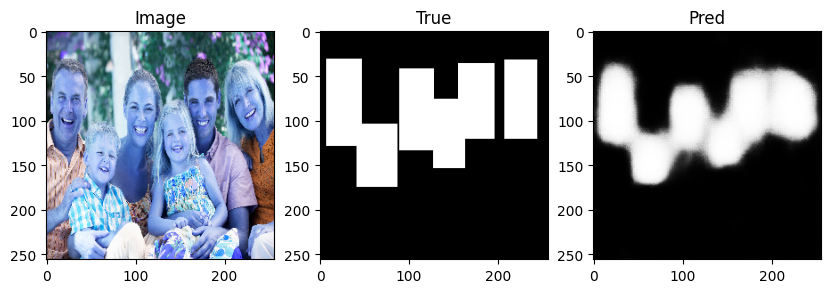

In [39]:
# Re-visualize the result
def show_prediction(i):
    pred = model.predict(X_val[i:i+1])[0]

    plt.figure(figsize=(10,4))

    plt.subplot(1,3,1)
    plt.imshow(X_val[i])
    plt.title("Image")

    plt.subplot(1,3,2)
    plt.imshow(y_val[i].squeeze(), cmap='gray')
    plt.title("True")

    plt.subplot(1,3,3)
    plt.imshow(pred.squeeze(), cmap='gray')
    plt.title("Pred")

    plt.show()

show_prediction(0)

In [40]:
plt.savefig('face_segmentation_result.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


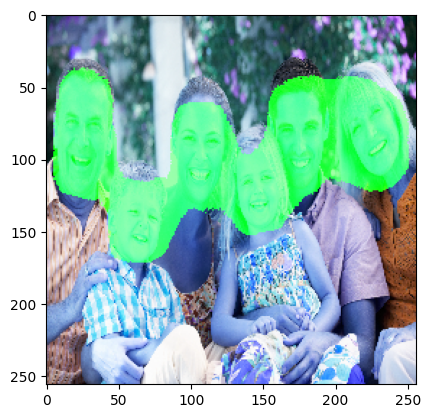

In [41]:
result = predict_and_overlay(model, X_val[0])
plt.imshow(result)

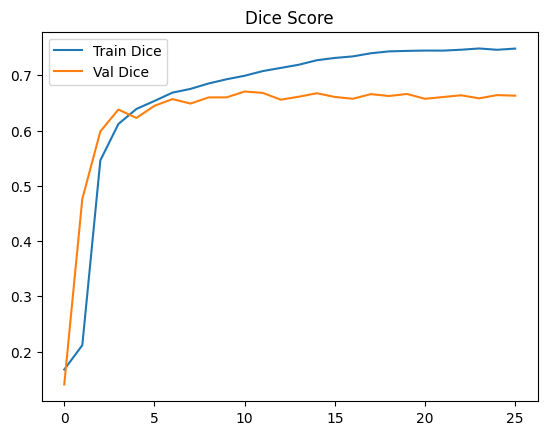

In [42]:
# Re-plot the training curves
plt.plot(history.history['dice_coefficient'], label='Train Dice')
plt.plot(history.history['val_dice_coefficient'], label='Val Dice')

plt.legend()
plt.title("Dice Score")
plt.show()

In [43]:
plt.savefig('Training_Curves.png', dpi=300, bbox_inches='tight')

<Figure size 640x480 with 0 Axes>

In [44]:
# Final Evaluation
loss = results[0]
dice = results[1]
iou = results[2]
f1_score = results[3]

print(f"Loss: {loss:.4f}")
print(f"Dice: {dice:.4f}")
print(f"IoU: {iou:.4f}")
print(f"F1 Score: {f1_score:.4f}")

Loss: 0.5582
Dice: 0.6736
IoU: 0.5078
F1 Score: 0.7056


### The metrics are calculated by
Dice = 2 × (Overlap) / (Total pixels)
IoU = Intersection / Union

In [45]:
def compute_metrics(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    dice = (2 * intersection + 1) / (np.sum(y_true) + np.sum(y_pred) + 1)
    iou = intersection / (np.sum(y_true) + np.sum(y_pred) - intersection + 1e-7)
    
    f1 = dice  # F1-score = Dice in binary segmentation

    return dice, iou, f1

In [46]:
pred = model.predict(X_val[0:1])[0]
pred = (pred > 0.5).astype(np.uint8)

dice, iou, f1 = compute_metrics(y_val[0], pred)

print("Dice:", dice)
print("IoU:", iou)
print("F1 Score:", f1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Dice: 0.852823488883589
IoU: 0.7434049434015089
F1 Score: 0.852823488883589
